In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score)
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE
print("✓ Imports done")

✓ Imports done


In [3]:
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [4]:
print("=== AVERAGE VALUES BY CLASS ===")
print(df.groupby('Class')[['Amount', 'V1', 'V2', 'V3', 'V4']].mean())

=== AVERAGE VALUES BY CLASS ===
           Amount        V1        V2        V3        V4
Class                                                    
0       88.291022  0.008258 -0.006271  0.012171 -0.007860
1      122.211321 -4.771948  3.623778 -7.033281  4.542029


In [5]:
target_col = 'Class'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)
print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("Fraud count:", y.sum())
print("Legit count:", (y==0).sum())

Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
X shape: (284807, 30)
Fraud count: 492
Legit count: 284315


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"Train size: {X_train_bal.shape}")
print(f"Class 0: {(y_train_bal==0).sum()}, Class 1: {(y_train_bal==1).sum()}")

Train size: (454902, 30)
Class 0: 227451, Class 1: 227451


In [7]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_bal, y_train_bal)
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]
print("✓ Logistic Regression done")

print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_bal, y_train_bal)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:,1]
print("✓ Decision Tree done")

print("Training Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train_bal, y_train_bal)
nb_pred = nb_model.predict(X_test)
nb_prob = nb_model.predict_proba(X_test)[:,1]
print("✓ Naive Bayes done")

print("\n✅ All models done!")

Training Logistic Regression...
✓ Logistic Regression done
Training Decision Tree...
✓ Decision Tree done
Training Naive Bayes...
✓ Naive Bayes done

✅ All models done!


In [8]:
def evaluate_threshold(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    r = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model':     name,
        'Threshold': threshold,
        'Precision': round(r['1']['precision'], 4),
        'Recall':    round(r['1']['recall'],    4),
        'F1-Score':  round(r['1']['f1-score'],  4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 4)
    }

results_final = []
for name, prob in [('Logistic Regression', lr_prob),
                   ('Decision Tree',       dt_prob),
                   ('Naive Bayes',         nb_prob)]:
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, prob)
    
    # Find threshold that gives best F1
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    results_final.append(
        evaluate_threshold(name, y_test, prob, best_threshold)
    )
    print(f"{name}: best threshold = {best_threshold:.3f}")

results_final_df = pd.DataFrame(results_final)
print("\n=== FINAL RESULTS WITH OPTIMAL THRESHOLD ===")
print(results_final_df.to_string(index=False))
results_final_df.to_csv('results_table.csv', index=False)
print("\n✅ results_table.csv saved!")

Logistic Regression: best threshold = 1.000
Decision Tree: best threshold = 0.999
Naive Bayes: best threshold = 1.000

=== FINAL RESULTS WITH OPTIMAL THRESHOLD ===
              Model  Threshold  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression   1.000000     0.8333  0.8163    0.8247   0.9710
      Decision Tree   0.999156     0.4783  0.7857    0.5946   0.8689
        Naive Bayes   1.000000     0.0991  0.8061    0.1765   0.9646

✅ results_table.csv saved!


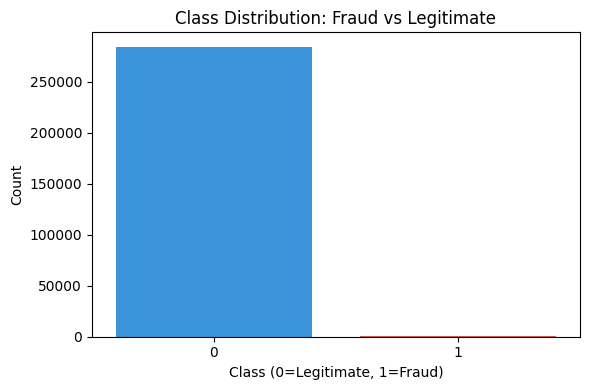

✓ fig1 saved


In [16]:
# Figure 1: Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#2196F3', '#F44336'])
plt.title('Class Distribution: Fraud vs Legitimate')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('fig1_class_distribution.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig1 saved")

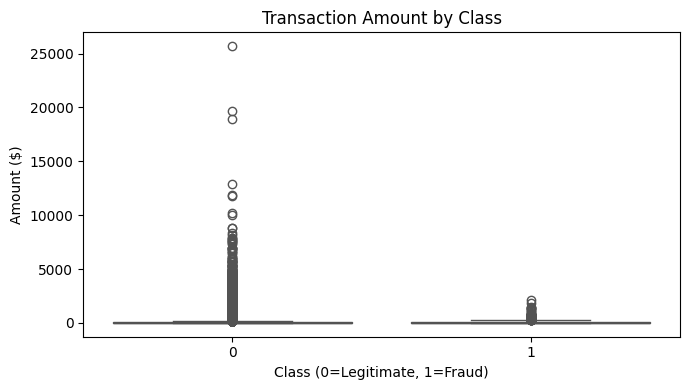

✓ fig2 saved


In [17]:
# Figure 2: Transaction Amount by Class
plt.figure(figsize=(7, 4))
sns.boxplot(x='Class', y='Amount', data=df,
            palette=['#2196F3', '#F44336'])
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.savefig('fig2_amount_by_class.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig2 saved")

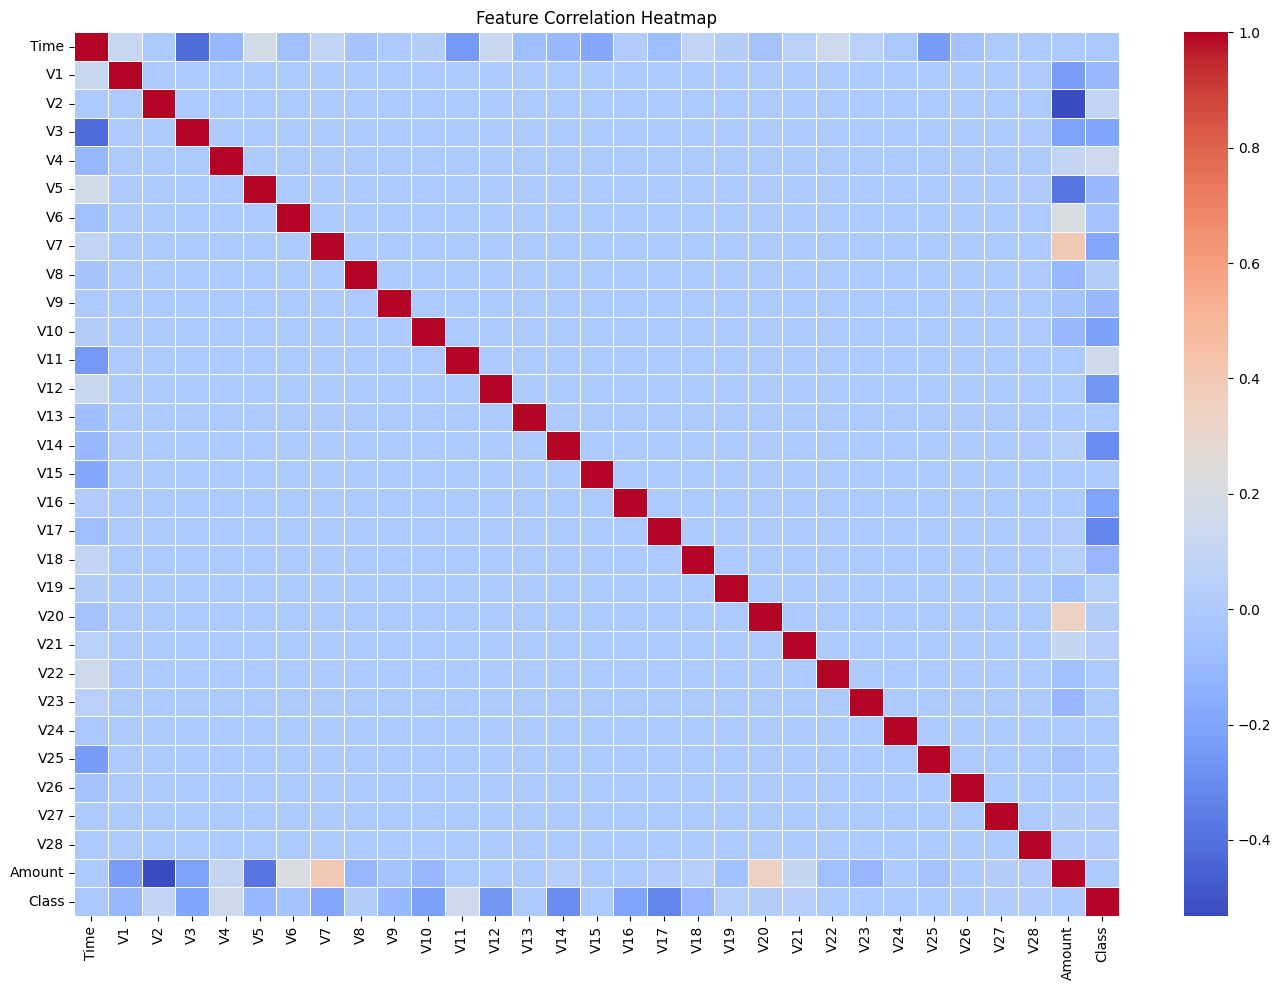

✓ fig3 saved


In [18]:
# Figure 3: Correlation Heatmap (numeric only)
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig3 saved")

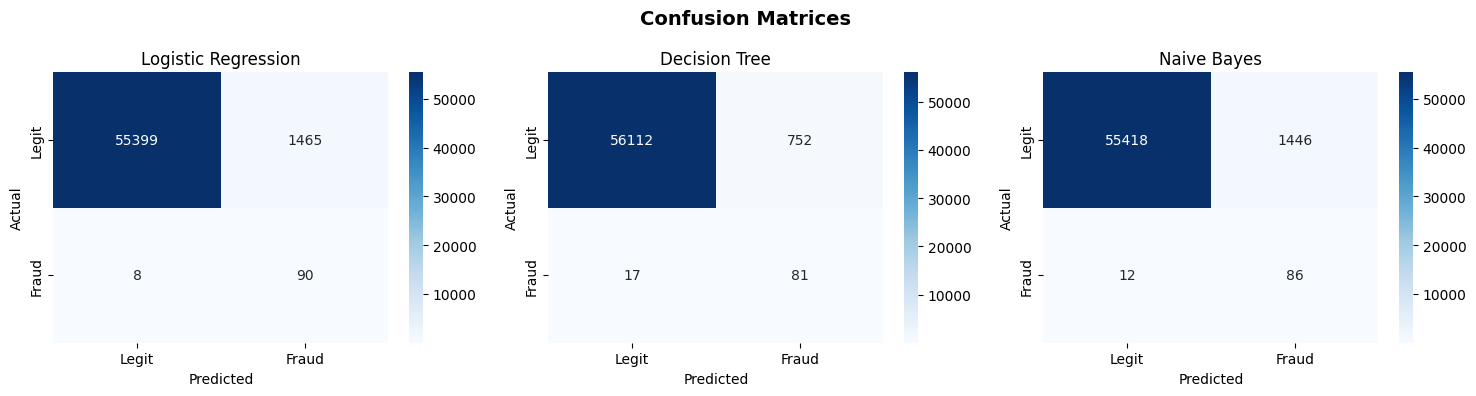

✓ fig4 saved


In [19]:
# Figure 4: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', lr_pred),
    ('Decision Tree',       dt_pred),
    ('Naive Bayes',         nb_pred)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_confusion_matrices.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig4 saved")

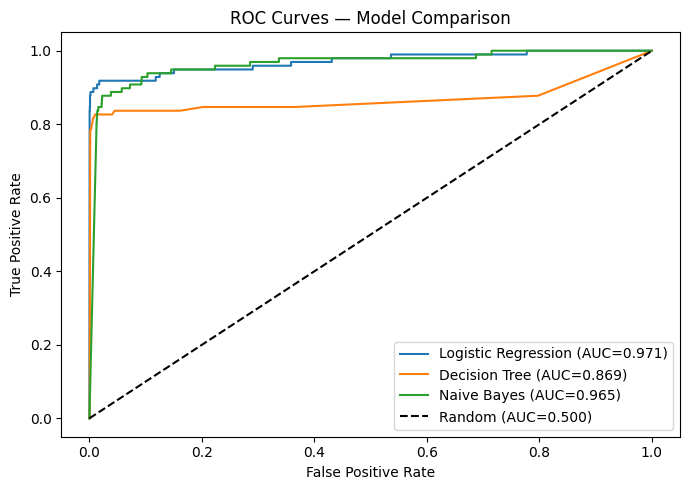

✓ fig5 saved


In [20]:
# Figure 5: ROC Curves
plt.figure(figsize=(7, 5))
for name, prob in [('Logistic Regression', lr_prob),
                   ('Decision Tree',       dt_prob),
                   ('Naive Bayes',         nb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('fig5_roc_curves.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig5 saved")

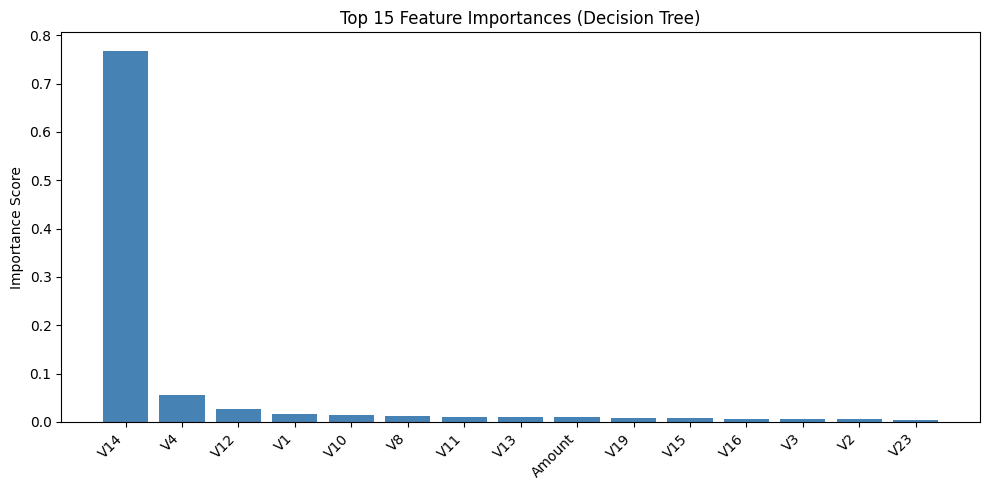

✓ fig6 saved


In [21]:
# Figure 6: Feature Importance (Decision Tree)
feature_names = df.drop(columns=['Class']).columns.tolist()
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(10, 5))
plt.bar(range(len(indices)), importances[indices], color='steelblue')
plt.xticks(range(len(indices)),[feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 15 Feature Importances (Decision Tree)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('fig6_feature_importance.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig6 saved")